# Training algorithm for O2 gapfill
    - Needs to enter a 6 digit input parameter as follows : 
    - First digit = Algorithm type (1=RF, 2=NN)
    - Second digit = Data Source (1=Ship only, 2=Ship+Argo)
    - Third digit = Ocean basin (1=Atlantic, 2=Pacific, 3=Indian, 4=Southern, 5=Arctic， 6=Mediterranean)
    - Fourth digit = T/S data source (1=EN4, 2=ORAS4, 3=SODA3.4.2, 4=EN4/C14)
    - Fifth digit = predictor variable set (1=[T,S,p,lon,lat,year,month], 2=[T,S,p,lon,lat,year,cos/sin_month], 3=[T,S,p,lon,lat,year,cos/sin_month,sigma-theta], 4=[T,S,p,lon,lat,year,cos/sin_month,sigma-theta,N2], 5=[T,S,p,lon,lat,cos/sin_month], 6=[T,S,p,lon,lat,GlobalSST,cos/sin_month])
    - Sixth digit = hyperparameter set (1=default, 2=preset hyperparameters, 4=DKCV)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import sklearn as skl
import gsw
import cartopy.crs as ccrs
from scipy.interpolate import interp1d
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
# version information
ver = '1.2.2.6.2.4'
# The version information will determine which basin / algorithm will be used to calculate the O2 maps. 
o2_cutoff = 600 # this is an arbitrary defined cut-off value to remove very large O2 input data from Argo
#
! mkdir -p /glade/derecho/scratch/qzhang459/EMU2/CMIP6/IPSL-CM6A-LR/input
dirn=f'/glade/derecho/scratch/qzhang459/EMU2/CMIP6/IPSL-CM6A-LR/input'
# combine OSD, CTD and PFL equally
eqave=0
# eqave=0 means the o2 value is weighted by profile count

### display selection

In [3]:
selection = ver.split('.')
basin = ['Atlantic','Pacific','Indian','Southern','Arctic','Mediterranean']
#
if selection[0] == '1':
    print('Random Forst algorithm will be used.')
    alg = 'RF'
elif selection[0] == '2':
    print('Neural Network algorithm will be used.')
    alg = 'NN'
else:
    print('error - incorrect algorithm type')
#
if selection[1] == '1':
    print('Ship-based O2 data will be used. ')
elif selection[1] == '2':
    print('Ship-based and Argo-O2 data will be used. ')
elif selection[1] == '3':
    print('Ship-based and modified Argo-O2 data will be used. ')
else:
    print('error - incorrect input data type')
#
if selection[2] == '1':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
elif selection[2] == '2':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
elif selection[2] == '3':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
elif selection[2] == '4':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
elif selection[2] == '5':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
elif selection[2] == '6':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
else:
    print('error - incorrect O2 data type')
#
if selection[3] == '1':
    print('EN4 dataset will be used for T/S input. ')
    endyear=2021
elif selection[3] == '2':
    print('ORAS4 dataset will be used for T/S input. ')
    endyear=2018
elif selection[3] == '3':
    print('SODA3.4.2 dataset will be used for T/S input. ')
elif selection[3] == '4':
    print('EN4 (C14) dataset will be used for T/S input. ')
    endyear=2024
elif selection[3] == '6':
    print('IPSL dataset will be used for T/S input. ')
    endyear=2023
else:
    print('error - incorrect T/S data type')
#
if selection[4] == '1':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, month')
elif selection[4] == '2':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month)')
elif selection[4] == '3':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month), sigma0')
elif selection[4] == '4':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month), sigma0, N2')
#NEW
elif selection[4] == '5A':
    print('Predictor variables include Ta, Sa, lon, lat, depth (pressure), cos(month), sin(month) with O2 anomaly')
elif selection[4] == '6':
    print('Predictor variables include T, S, lon, lat, depth (pressure), GMT, cos(month), sin(month)')
elif selection[4] == '60':
    print('Predictor variables include T, S, lon, lat, depth (pressure), cos(month), sin(month)')
elif selection[4] == '61':
    print('Predictor variables include lon, lat, depth (pressure), o2sol, cos(month), sin(month)')
elif selection[4] == '7':
    print('Predictor variables include T, S, lon, lat, depth (pressure), cos(month), sin(month)')
elif selection[4] == '8':
    print('Predictor variables include T, S, lon, lat, depth (pressure), GMT, o2sol, cos(month), sin(month)')
#NEW
else:
    print('error - incorrect predictor variable type')
#
if selection[5] == '1':
    print('Hyperparameter set is optimized via K-fold CV')
elif selection[5] == '2':
    print('A pre-set hyperparameter set is used')
elif selection[5] == '4':
    print('New train/test splid and K-fold cross validation')
else:
    print('error - incorrect hyperparameter type')

Random Forst algorithm will be used.
Ship-based and Argo-O2 data will be used. 
Pacific Ocean will be mapped
IPSL dataset will be used for T/S input. 
Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month)
New train/test splid and K-fold cross validation


In [4]:
# Define the input and output folders
#
os.system('echo $USER > userid')
usrid=np.genfromtxt('userid',dtype='<U16')
os.system('rm userid')
diro = '/glade/derecho/scratch/'+str(usrid)+'/ML4O2_temp/'
if selection[3]=='1':
    dirf = '/glade/campaign/univ/ugit0034/EN4/L09_20x180x360/'
    dbase='EN4_TSN2_L09_180x360_'
    roll180=0
elif selection[3]=='2':
    dirf = '/glade/campaign/univ/ugit0034/ORAS4/TSN2/'
    dbase='ORAS4_TSN2_'
    roll180=1
elif selection[3]=='4':
    dirf = '/glade/campaign/univ/ugit0034/EN4/C14/'
    dbase='EN4_C14_180x360_'
    roll180=0
elif selection[3]=='6':
    dirf = '/glade/campaign/univ/ugit0034/cmip6/IPSL-CM6A-LR/TS/'
    dbase='TS_IPSL-CM6A-LR_19652100'
    roll180=0
# This is where the source data is ---
#dirin = '/glade/campaign/univ/ugit0034/WOD18_OSDCTD/'
#fargo = '/glade/campaign/univ/ugit0034/bgcargo/o2_Global_ARGO_Type12_47lev.nc'
dirin = '/glade/campaign/univ/ugit0034/Zhankun/'
#
fosd='_1x1bin_osd_1965-2022'
fctd='_1x1bin_ctd_1987-2022'
fpfl='_1x1bin_pfl_2005-2022'
var=['Oxygen']
os.system('mkdir -p '+diro)
os.system('mkdir -p '+diro+'temp')

0

### Preprocessing the data
- New in 2025
- Depth is extended to 1800m
- Training data is including Global mean SST rather than year

In [5]:
# obtain vertical grid
ds=xr.open_dataset(dirin+var[0]+fosd+'.nc')
Z=ds.depth.to_numpy()
Nz=np.size(Z)
print(Nz,Z)

63 [   0.    5.   10.   15.   20.   25.   30.   35.   40.   45.   50.   55.
   60.   65.   70.   75.   80.   85.   90.   95.  100.  125.  150.  175.
  200.  225.  250.  275.  300.  325.  350.  375.  400.  425.  450.  475.
  500.  550.  600.  650.  700.  750.  800.  850.  900.  950. 1000. 1050.
 1100. 1150. 1200. 1250. 1300. 1350. 1400. 1450. 1500. 1550. 1600. 1650.
 1700. 1750. 1800.]


In [6]:
# select analysis period
# endyear=2023
# do not change the start year from 1965 (this is when Carpenter 1965 established modern Winkler method)
yrs=np.arange(1965,endyear,1)
yrs

array([1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975,
       1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986,
       1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997,
       1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
       2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022])

Pacific Ocean will be mapped


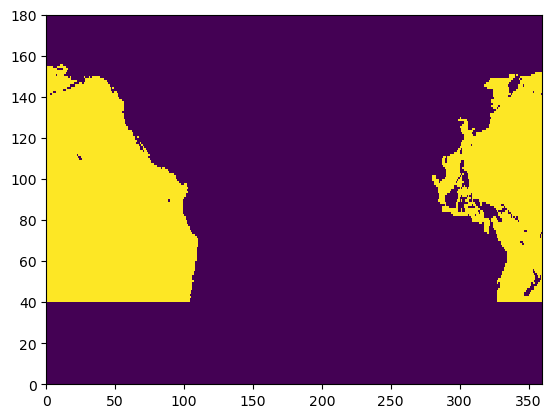

In [7]:
# basin mask
dsm=xr.open_dataset('/glade/campaign/univ/ugit0034/wod18/basin_mask_01.nc')
ma = dsm.basin_mask.isel(depth=0).to_numpy()
#
if selection[2] == '1':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
    mask = np.where(ma==1,1,0)
elif selection[2] == '2':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
    mask = np.where(ma==2,1,0)
elif selection[2] == '3':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
    mask = np.where((ma==3)|(ma==56),1,0)
elif selection[2] == '4':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
    mask = np.where(ma==10,1,0)
elif selection[2] == '5':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
    mask = np.where((ma==11)|(ma==16)|(ma==17),1,0)
elif selection[2] == '6':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
    mask = np.where(ma==4,1,0)
else:
    print('error - incorrect O2 data type')
#
plt.pcolormesh(mask)

In [8]:
# NEW in 2025
# Obtain O2 data from observational dataset
#
#  Argo O2 bias correction can happen here!
#
Nyr=np.size(yrs)
Nt=Nyr*12
mon=["%.2d" % i for i in np.arange(1,13,1)]
#
o2=np.zeros((Nt,Nz,180,360))
#
ds1=xr.open_dataset(dirin+var[0]+fosd+'.nc')
ds2=xr.open_dataset(dirin+var[0]+fctd+'.nc')
ds3=xr.open_dataset(dirin+var[0]+fpfl+'.nc')
#
for year in yrs:
    ytmp=year%10
    if ytmp==0:
        print(str(year))
    tr=12*(year-1965)
    timeind0=(year-2005)*12
    if (year<1987):#|(selection[1]=='1'):
        o2[tr:(tr+12),:,:,:]=ds1.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
    elif (year<2005)|(selection[1]=='1'):
        o2b = ds1.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        cntb= ds1.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        o2c = ds2.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        cntc= ds2.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        o2b=np.where(np.isnan(o2b),0,o2b)
        o2c=np.where(np.isnan(o2c),0,o2c)
        if eqave == 1:
            cntb[cntb>1]=1 # equal weights
            cntc[cntc>1]=1
        o2[tr:(tr+12),:,:,:]=(o2b*cntb+o2c*cntc)/(cntb+cntc)
    elif (selection[1]=='2'):
        o2b = ds1.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        cntb= ds1.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        o2c = ds2.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        cntc= ds2.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        o2p = ds3.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        cntp= ds3.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        o2b=np.where(np.isnan(o2b),0,o2b)
        o2c=np.where(np.isnan(o2c),0,o2c)
        o2p=np.where(np.isnan(o2p),0,o2p)
        if eqave == 1:
            cntb[cntb>1]=1 # equal weights
            cntc[cntc>1]=1
            cntp[cntp>1]=1
        o2[tr:(tr+12),:,:,:]=(o2b*cntb+o2c*cntc+o2p*cntp)/(cntb+cntc+cntp)
    elif (selection[1]=='3'):
        o2b = ds1.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        cntb= ds1.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        o2c = ds2.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        cntc= ds2.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        o2p = ds3.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()+argo_offset
        cntp= ds3.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        o2b=np.where(np.isnan(o2b),0,o2b)
        o2c=np.where(np.isnan(o2c),0,o2c)
        o2p=np.where(np.isnan(o2p),0,o2p)
        if eqave == 1:
            cntb[cntb>1]=1 # equal weights
            cntc[cntc>1]=1
            cntp[cntp>1]=1
        o2[tr:(tr+12),:,:,:]=(o2b*cntb+o2c*cntc+o2p*cntp)/(cntb+cntc+cntp)
    # result quick check
    #tmp=o2[tr:(tr+12),:,:,:].flatten()
    #print(year,np.nanmax(tmp),np.nanmin(tmp))

1970
1980
1990
2000
2010
2020


In [9]:
#
# Obtain T/S data from observational gridded dataset
#
# t=np.zeros((Nt,Nz,180,360))
# s=np.zeros((Nt,Nz,180,360))
# #
# for year in yrs:
#     ytmp=year%10
#     if ytmp==0:
#         print(str(year))
#     tr=12*(year-1965)
#     for mn in range(12):
#         ds = xr.open_dataset(dirf+dbase+str(year)+mon[mn]+'.nc')
#         print(dirf+dbase+str(year)+mon[mn]+'.nc')
#         if roll180==1:
#             ds.coords['lon'] = (ds.coords['lon'] + 180) % 360 - 180
#             ds = ds.sortby(ds.lon)
#         s[tr+mn,:,:,:]=ds.SA.interp(depth=Z).to_numpy().squeeze()
#         t[tr+mn,:,:,:]=ds.CT.interp(depth=Z).to_numpy().squeeze()

dtryts = xr.open_dataset('/glade/campaign/univ/ugit0034/cmip6/IPSL-CM6A-LR/TS/TS_IPSL-CM6A-LR_19652100.nc')
n2=np.zeros((Nt,Nz,180,360)).squeeze()
t=dtryts.CT.sel(time=slice('1965-01','2022-12')).to_numpy().squeeze()
s=dtryts.SA.sel(time=slice('1965-01','2022-12')).to_numpy().squeeze()
# do2sol = xr.open_dataset('o2sol_IPSL-CM6A-LR.nc')
# o2sol = do2sol.o2sol.sel(time=slice('1965-01','2022-12')).to_numpy().squeeze()

In [10]:
# get coordinates
x=ds.lon.to_numpy() 
# use alternative x coordinate: longitude - 20
xa0 = x - 20
xalt = np.where(xa0<0,xa0+360,xa0)
#
y=ds.lat.to_numpy()
xi=np.arange(0,360,1)
yi=np.arange(0,180,1)
xx,yy=np.meshgrid(xalt,y)
xxi,yyi=np.meshgrid(xi,yi)

In [11]:
# extract mask 
mask= dsm.basin_mask.sel(depth=Z)

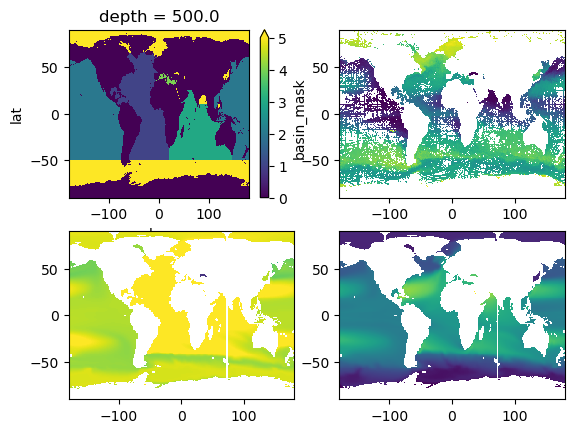

In [12]:
# take a look at the data
fig,ax=plt.subplots(2,2)
# select 500m for plotting
kind=[idx for idx,elem in enumerate(Z) if elem==500]
#
mask.isel(depth=kind).plot(ax=ax[0,0],vmin=0,vmax=5,label='basin_mask')
ax[0,1].pcolormesh(x,y,np.nanmean(o2[:,kind[0],:,:],axis=0))
ax[1,0].pcolormesh(x,y,np.nanmean(s[:,kind[0],:,:],axis=0),vmin=32,vmax=35)
ax[1,1].pcolormesh(x,y,np.nanmean(t[:,kind[0],:,:],axis=0))

In [13]:
# prepare basin wise array

In [14]:
# prepare depth lat lon time data
xx1  = np.tile(xx,[Nz,1,1])
yy1  = np.tile(yy,[Nz,1,1])
xxSO = (yy+90)*np.cos(np.deg2rad(xx))
yySO = (yy+90)*np.sin(np.deg2rad(xx))
xxAO = (-yy+90)*np.cos(np.deg2rad(xx))
yyAO = (-yy+90)*np.sin(np.deg2rad(xx))
#
xx1SO = np.tile(xxSO,[Nz,1,1])
yy1SO = np.tile(yySO,[Nz,1,1])
xx1AO = np.tile(xxAO,[Nz,1,1])
yy1AO = np.tile(yyAO,[Nz,1,1])
ztmp  = np.tile(Z,[180,360,1])
zz1   = np.transpose(ztmp,[2,0,1])

In [15]:
dsg=xr.open_dataset('IPSL-CM6A-LR_Global_SST.nc')
GMT=dsg.sst.sel(time=slice('1965-01','2022-12')).to_numpy()
print(Nt,GMT.size)

696 696


In [16]:
Nlev=63
#Nlev=47
bnames=['atlantic','pacific','indian','southern','arctic','mediterranean']
bindex=[1,2,3,10,11,4]
#
for bid in np.arange(2,3,1):
    dsa1=np.array([])
    dta1=np.array([])
    do2sola1 = np.array([])
    xx1s=np.array([])
    yy1s=np.array([])
    zz1s=np.array([])
    tt1s=np.array([])
    tc1s=np.array([])
    doa1s=np.array([])
    GMT1=np.array([])
    bname0=bnames[bid-1]
    #
    for n in range(GMT.size):
        t0 = n
        t1 = t0%12
        tt1 = np.ones((Nz,180,360))*t0
        tc1 = np.ones((Nz,180,360))*t1
        GMT0= np.ones((Nz,180,360))*GMT[n]
        #if t1==0:
        #    print(n/12+1965)
        if n<Nt:
            o20=o2[n,:,:,:]
            # o2sol0=o2sol[n,:,:,:]
            theta0=t[n,:,:,:]
            s0=s[n,:,:,:]
            tmp = o20+theta0+s0
        else:
            theta0=t[n,:,:,:]
            s0=s[n,:,:,:]
            tmp = theta0+s0
        #
        #print(bnames[bid-1])
        if bid==3:
            dd = np.where((mask==3)|(mask==56),tmp,np.nan)
        else:
            dd = np.where(mask==bindex[bid-1],tmp,np.nan)
            
        if bid==6:
            dd = np.where((mask==4)|(mask==16)|(mask==17),tmp,np.nan)
        else:
            dd = np.where(mask==bindex[bid-1],tmp,np.nan)
        #
        dsa1=np.concatenate((dsa1,s0[np.isnan(dd)==False]))
        dta1=np.concatenate((dta1,theta0[np.isnan(dd)==False]))
        # do2sola1=np.concatenate((do2sola1,o2sol0[np.isnan(dd)==False]))
        #
        if bid == 4:
            xx1s=np.concatenate((xx1s,xx1SO[np.isnan(dd)==False]))
        elif bid == 5:
            xx1s=np.concatenate((xx1s,xx1AO[np.isnan(dd)==False]))
        else:
            xx1s=np.concatenate((xx1s,xx1[np.isnan(dd)==False]))
        if bid == 4:
            yy1s=np.concatenate((yy1s,yy1SO[np.isnan(dd)==False]))
        elif bid == 5:
            yy1s=np.concatenate((yy1s,yy1AO[np.isnan(dd)==False]))
        else:
            yy1s=np.concatenate((yy1s,yy1[np.isnan(dd)==False]))
        #
        zz1s=np.concatenate((zz1s,zz1[np.isnan(dd)==False]))
        tt1s=np.concatenate((tt1s,tt1[np.isnan(dd)==False]))
        GMT1=np.concatenate((GMT1,GMT0[np.isnan(dd)==False]))
        tc1s=np.concatenate((tc1s,tc1[np.isnan(dd)==False]))
        
        if n<Nt:
            doa1s=np.concatenate((doa1s,o20[np.isnan(dd)==False]))
        #
    #
    Nsample = np.size(doa1s)
    print(bname0,Nsample)    
    np.save(f'{dirn}/o20_{bname0}_1x1_{Nlev}lev.npy',doa1s)
    np.save(f'{dirn}/month0_{bname0}_1x1_{Nlev}lev.npy',tc1s)
    np.save(f'{dirn}/time0_{bname0}_1x1_{Nlev}lev.npy',tt1s)
    np.save(f'{dirn}/depth0_{bname0}_1x1_{Nlev}lev.npy',zz1s)
    np.save(f'{dirn}/lon0_{bname0}_1x1_{Nlev}lev.npy',xx1s)
    np.save(f'{dirn}/lat0_{bname0}_1x1_{Nlev}lev.npy',yy1s)
    np.save(f'{dirn}/t0_{bname0}_1x1_{Nlev}lev.npy',dta1)
    np.save(f'{dirn}/s0_{bname0}_1x1_{Nlev}lev.npy',dsa1)
    np.save(f'{dirn}/GMT0_{bname0}_1x1_{Nlev}lev.npy',GMT1)

pacific 4429293


In [17]:
# generate data matrix and standardize it
if selection[4] == '1':
    X = np.array([dsa1, dta1, xx1, yy1, zz1, tt1, tc1])
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, month')
elif selection[4] == '2':
    X = np.array([dsa1, dta1, xx1s, yy1s, zz1s, tt1s, np.cos(2*np.pi*tc1s/12), np.sin(2*np.pi*tc1s/12)])
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month)')
elif selection[4] == '3':
    X = np.array([dsa1, dta1, xx1, yy1, zz1, tt1, np.cos(2*np.pi*tc1/12), np.sin(2*np.pi*tc1/12), dsga1])
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month), sigma')
elif selection[4] == '4':
    X = np.array([dsa1, dta1, xx1, yy1, zz1, tt1, np.cos(2*np.pi*tc1/12), np.sin(2*np.pi*tc1/12), dsga1, dn2a1])
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month), sigma, N2')
elif selection[4] == '5':
    X = np.array([dsa1, dta1, xx1, yy1, zz1, np.cos(2*np.pi*tc1/12), np.sin(2*np.pi*tc1/12)])
    print('Predictor variables include T, S, lon, lat, depth (pressure), cos(month), sin(month)')
elif selection[4] == '6':
    X = np.array([dsa1, dta1, xx1s, yy1s, zz1s, GMT1, np.cos(2*np.pi*tc1s/12), np.sin(2*np.pi*tc1s/12)])
    print('Predictor variables include T, S, lon, lat, depth (pressure), GMT, cos(month), sin(month)')
elif selection[4] == '60':
    X = np.array([dsa1, dta1, xx1s, yy1s, zz1s, np.cos(2*np.pi*tc1s/12), np.sin(2*np.pi*tc1s/12)])
    print('Predictor variables include T, S, lon, lat, depth (pressure), cos(month), sin(month)')
elif selection[4] == '61':
    X = np.array([xx1s, yy1s, zz1s, do2sola1, np.cos(2*np.pi*tc1s/12), np.sin(2*np.pi*tc1s/12)])
    print('Predictor variables include lon, lat, depth (pressure), o2sol, cos(month), sin(month)')
elif selection[4] == '7':
    X = np.array([dsa1, dta1, xx1s, yy1s, zz1s, tt1s, GMT1, np.cos(2*np.pi*tc1s/12), np.sin(2*np.pi*tc1s/12)])
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, GMT, cos(month), sin(month)')
elif selection[4] == '8':
    X = np.array([dsa1, dta1, xx1s, yy1s, zz1s, GMT1, do2sola1, np.cos(2*np.pi*tc1s/12), np.sin(2*np.pi*tc1s/12)])
    print('Predictor variables include T, S, lon, lat, depth (pressure), GMT, o2sol, cos(month), sin(month)')
else:
    print('error - incorrect predictor variable type')
#X = np.array([dsa1, dta1, xx1, yy1, tt1, tc1])
#
y = doa1s
#
Xm = np.mean(X,axis=1)
Xstd = np.std(X,axis=1)
#
N=np.size(y)
# normalize x and y
Xa = (X.T - Xm)/Xstd
ym = np.mean(y)
ystd = np.std(y)
ya = (y-ym)/ystd
#
dirout=f'/glade/derecho/scratch/{usrid}/EMU2/CMIP6/IPSL-CM6A-LR/'
np.savez(dirout+f'ML_params_v{ver}.npz',Xm=Xm,Xstd=Xstd,ym=ym,ystd=ystd)

Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month)
